In [3]:
print(type(mat_contents['m']), mat_contents['m'].shape, mat_contents['m'])
print(type(mat_contents['n']), mat_contents['n'].shape, mat_contents['n'])
print(mat_contents.keys())

<class 'numpy.ndarray'> (1, 1) [[168]]
<class 'numpy.ndarray'> (1, 1) [[192]]
dict_keys(['__header__', '__version__', '__globals__', 'faces', 'n', 'm', 'sub', 'nfaces', 'person'])


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from PIL import Image

plt.rcParams['figure.figsize'] = [10, 8]

mat_contents = scipy.io.loadmat('data/allFaces.mat')
faces = mat_contents['faces']

# .item() bezpiecznie wyciąga pojedynczą wartość niezależnie od kształtu (1,1), (1,), itp.
m = int(np.array(mat_contents['m']).item())
n = int(np.array(mat_contents['n']).item())
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

print('Rozmiar macierzy faces:', faces.shape)
print(f'Wymiary pojedynczego obrazu: {m} x {n}')
print('Liczba osób w bazie:', len(nfaces))

Rozmiar macierzy faces: (32256, 2410)
Wymiary pojedynczego obrazu: 168 x 192
Liczba osób w bazie: 38


In [5]:
trainingFaces = faces
avgFace = np.mean(trainingFaces, axis=1)

X = trainingFaces - np.tile(avgFace, (trainingFaces.shape[1], 1)).T
U, S, VT = np.linalg.svd(X, full_matrices=False)

print('U (eigenfaces):', U.shape)
print('S (wartości singularne):', S.shape)

U (eigenfaces): (32256, 2410)
S (wartości singularne): (2410,)


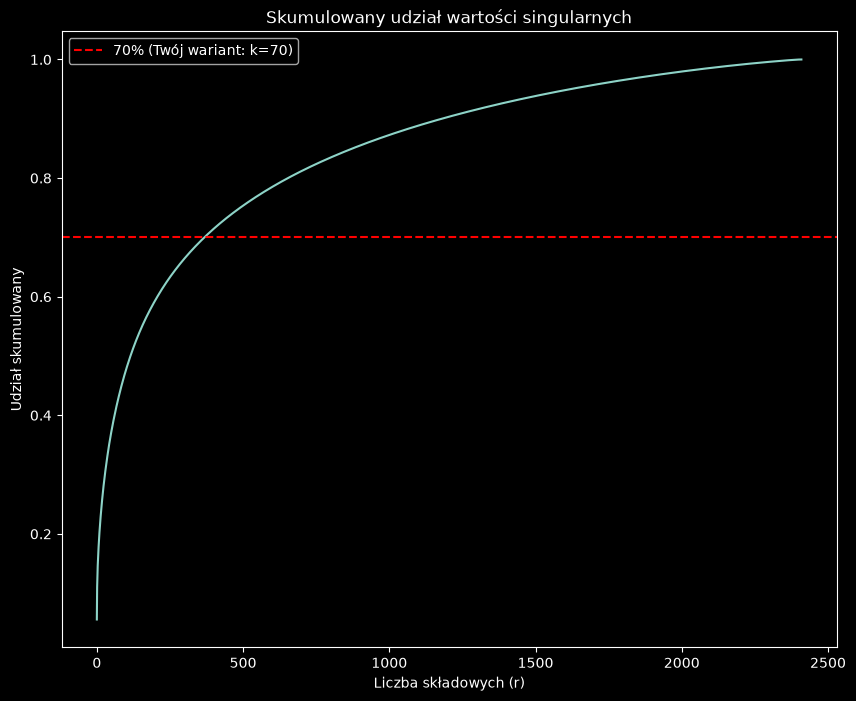

In [6]:
plt.figure()
plt.semilogy(S)
plt.title('Wartości singularne')
plt.show()

cum_share = np.cumsum(S) / np.sum(S)

plt.figure()
plt.plot(cum_share)
plt.axhline(0.70, color='r', linestyle='--', label='70% (Twój wariant: k=70)')
plt.title('Skumulowany udział wartości singularnych')
plt.xlabel('Liczba składowych (r)')
plt.ylabel('Udział skumulowany')
plt.legend()
plt.show()

In [7]:
k_percent = 0.70

r_needed = np.searchsorted(cum_share, k_percent) + 1
print(f'Liczba eigenfaces (r) potrzebna do zachowania {k_percent*100:.0f}% informacji: r = {r_needed}')

Liczba eigenfaces (r) potrzebna do zachowania 70% informacji: r = 369


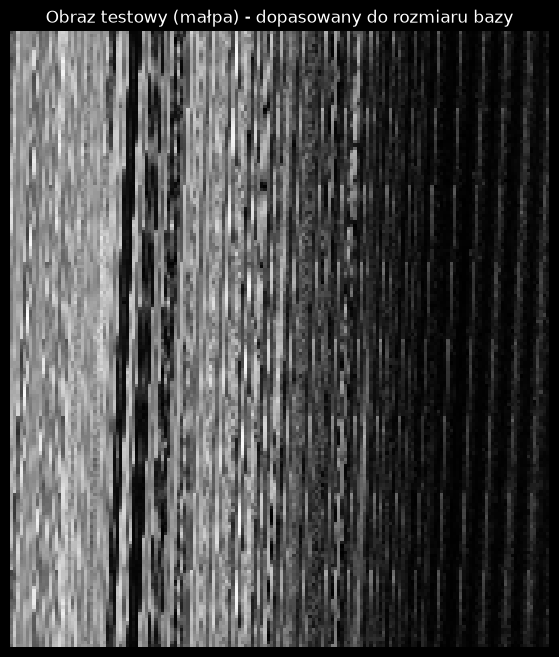

In [9]:
img = Image.open('data/malpa1.jpg').convert('L')
img_resized = img.resize((n, m))

monkey_vec = np.array(img_resized).T.flatten()

plt.imshow(np.reshape(monkey_vec, (m, n)).T, cmap='gray')
plt.title('Obraz testowy (małpa) - dopasowany do rozmiaru bazy')
plt.axis('off')
plt.show()

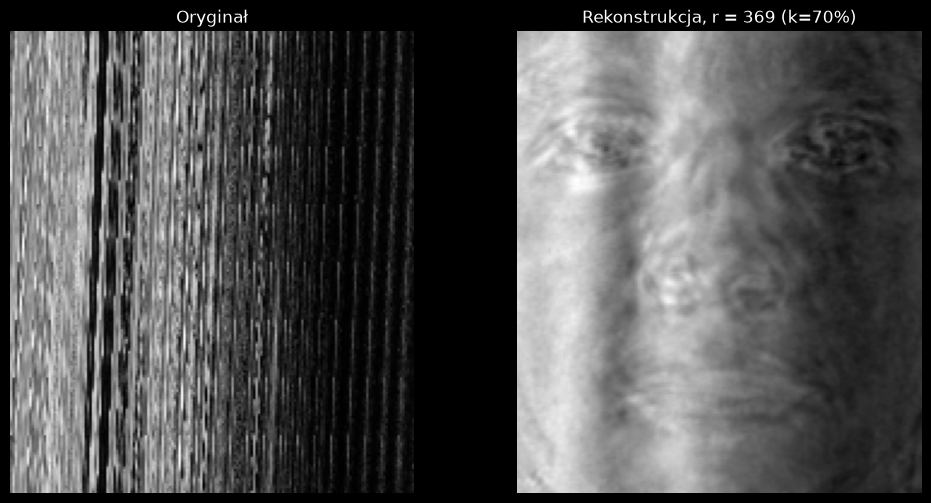

In [10]:
monkeyMS = monkey_vec - avgFace

Ur = U[:, :r_needed]
reconMonkey = avgFace + Ur @ (Ur.T @ monkeyMS)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.reshape(monkey_vec, (m, n)).T, cmap='gray')
axes[0].set_title('Oryginał')
axes[0].axis('off')

axes[1].imshow(np.reshape(reconMonkey, (m, n)).T, cmap='gray')
axes[1].set_title(f'Rekonstrukcja, r = {r_needed} (k={k_percent*100:.0f}%)')
axes[1].axis('off')

plt.show()

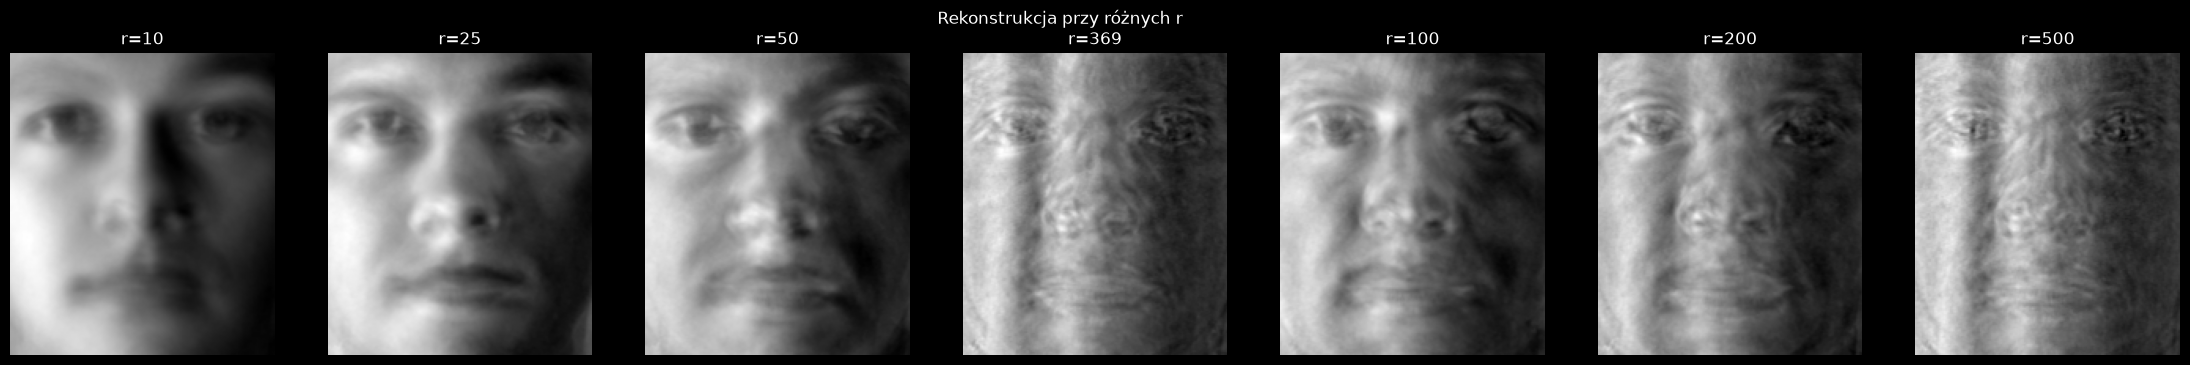

In [11]:
r_list = [10, 25, 50, r_needed, 100, 200, 500]

fig, axes = plt.subplots(1, len(r_list), figsize=(4*len(r_list), 4))
for ax, r in zip(axes, r_list):
    Ur = U[:, :r]
    recon = avgFace + Ur @ (Ur.T @ monkeyMS)
    ax.imshow(np.reshape(recon, (m, n)).T, cmap='gray')
    ax.set_title(f'r={r}')
    ax.axis('off')
plt.suptitle('Rekonstrukcja przy różnych r')
plt.show()